In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from pathlib import Path
img_path = Path("data/things-eeg2/imgs")

all_paths_train = sorted((img_path / "training_images").rglob("*.jpg"))
all_paths_test = sorted((img_path / "test_images").rglob("*.jpg"))

all_paths_test[:3]

[PosixPath('data/things-eeg2/imgs/test_images/00001_aircraft_carrier/aircraft_carrier_06s.jpg'),
 PosixPath('data/things-eeg2/imgs/test_images/00002_antelope/antelope_01b.jpg'),
 PosixPath('data/things-eeg2/imgs/test_images/00003_backscratcher/backscratcher_01b.jpg')]

In [3]:
import torch
from brain_image.data import EEGDatasetConfig
from brain_image.model.eeg_alignment import EEGAlignmentModel, EEGAlignmentConfig
import yaml


cp_dir = Path("logs/align-atms-clip_vith14-local-train/version_26")
with open(cp_dir / "hparams.yaml", "r") as f:
    eeg_config_content = yaml.safe_load(f)

eeg_config = EEGAlignmentConfig(**eeg_config_content["config"])
dataset_config = EEGDatasetConfig(**eeg_config_content["dataset_config"])
    
eeg_model = EEGAlignmentModel(eeg_config, dataset_config, modules_to_compile=[])
eeg_model.load_checkpoint(cp_dir / "checkpoints" / "last.ckpt", undo_compile=True)
eeg_model.eval()
eeg_model.requires_grad_(False)

EEGAlignmentModel(
  (loss): CrossEntropyLoss()
  (eeg_encoder): AtmsEEGEncoder(
    (encoder): iTransformer(
      (enc_embedding): DataEmbedding(
        (value_embedding): Linear(in_features=250, out_features=250, bias=True)
        (position_embedding): PositionalEmbedding()
        (temporal_embedding): TimeFeatureEmbedding(
          (embed): Linear(in_features=4, out_features=250, bias=False)
        )
        (dropout): Dropout(p=0.25, inplace=False)
        (subject_embedding): SubjectEmbedding(
          (subject_embedding): Embedding(10, 250)
        )
      )
      (encoder): Encoder(
        (attn_layers): ModuleList(
          (0): EncoderLayer(
            (attention): AttentionLayer(
              (inner_attention): FullAttention(
                (dropout): Dropout(p=0.25, inplace=False)
              )
              (query_projection): Linear(in_features=250, out_features=248, bias=True)
              (key_projection): Linear(in_features=250, out_features=248, bias=Tru

In [13]:
from brain_image.model.img_encoder import load_image_encoder, BaseImageEncoder

eeg_encoder = eeg_model.eeg_encoder.to("cuda")
eeg_encoder.compile()
clip_img_encoder = load_image_encoder("clip_vith14").to("cuda")
train_dataset = eeg_model.data_module.get_train_dataset()
test_dataset = eeg_model.data_module.get_test_dataset()
cache = eeg_model.tensor_cache

B = 128


In [7]:

from typing import Literal

from brain_image.data import TensorCache


def get_image_latent_from_cache(cache: TensorCache, img_path: Path, split: Literal["train", "test"]) -> torch.Tensor:
    return cache.get(str(img_path), "clip_vith14", split) 
    


In [15]:
from typing import Literal
import tqdm

from brain_image.data import EEGDataset, TensorCache, get_image_paths
import torch
from brain_image.data import batch_load_images
import tqdm

from torch.utils.data import Subset

from brain_image.model.eeg_encoder.eeg_encoder import EEGEncoder


@torch.no_grad()
def embed_data(
    split: Literal["train", "test"],
    dataset: EEGDataset,
    cache: TensorCache,
    batch_size: int,
    eeg_encoder: EEGEncoder,
    use_progressbar: bool = True,
    device="cuda",
):
    N, B = len(dataset), batch_size
    _eeg_latents = []
    _img_latents = []

    with tqdm.tqdm(
        total=N, disable=not use_progressbar, desc="Embedding data..."
    ) as pbar:
        for i in range(0, N, B):
            _eegs_datas = []
            _subs = []

            for j in range(i, min(i + B, N)):
                sample = dataset[j]

                _eegs_datas.append(sample["eeg_data"])
                _subs.append(sample["sub"])
                img_path = sample["img_path"]
                img_latent = get_image_latent_from_cache(cache, img_path, split)
                _img_latents.append(img_latent)


            eeg_data = torch.stack(_eegs_datas).to(device)
            subs = torch.tensor(_subs).to(device)

            eeg_latent = eeg_encoder(eeg_data, subs).detach().cpu()

            _eeg_latents.append(eeg_latent)
            pbar.update(B)

    return {
        "eeg_latents": torch.cat(_eeg_latents, dim=0),
        "img_latents": torch.stack(_img_latents, dim=0),
    }


LOAD_CACHE_IF_EXISTS = True
cached_latents_train_path = Path("tmp/all_latents_train.pt")
cached_latents_test_path = Path("tmp/all_latents_test.pt")

if LOAD_CACHE_IF_EXISTS and cached_latents_train_path.exists() and cached_latents_test_path.exists():
    cached_latents_train = torch.load(cached_latents_train_path)
    cached_latents_test = torch.load(cached_latents_test_path)
else:
    cached_latents_train = embed_data(
        "train",
        train_dataset,
        cache,
        B,
        eeg_encoder,
    )
    torch.save(cached_latents_train, cached_latents_train_path)

    cached_latents_test = embed_data(
        "test",
        test_dataset,
        cache,
        B,
        eeg_encoder,
    )
    torch.save(cached_latents_test, cached_latents_test_path)

In [ ]:


@torch.no_grad()
def embed_images(img_paths: list[Path], batch_size: int, encoder: BaseImageEncoder, use_progressbar: bool = True, device="cuda"):
    N, B = len(img_paths), batch_size
    all_embeds = []

    with tqdm.tqdm(total=N, disable=not use_progressbar, desc="Embedding data...") as pbar:
        for i in range(0, N, B):
            imgs = batch_load_images(img_paths[i:i+B]).to(device)
            embeds = encoder.encode(imgs).detach().cpu()
            all_embeds.append(embeds)
            pbar.update(B)

    return torch.cat(all_embeds, dim=0)

B = 512

LOAD_CACHE_IF_EXISTS = True
_cached_train_imgs_path = Path("tmp/all_imgs_train.pt")
if LOAD_CACHE_IF_EXISTS and _cached_train_imgs_path.exists():
    all_imgs_train = torch.load(_cached_train_imgs_path)
else:
    all_imgs_train = embed_images(all_paths_train, B, clip_img_encoder)
    torch.save(all_imgs_train, _cached_train_imgs_path)

In [5]:
del clip_img_encoder

In [16]:
from dataclasses import dataclass

from typing import Any, Literal
from torch import nn
from torch import Tensor

from diffusers.models.embeddings import TimestepEmbedding, Timesteps
from diffusers.schedulers.scheduling_ddpm import DDPMScheduler

from brain_image.configs import get_device


def get_activation(name: str):
    match name:
        case "silu":
            return nn.SiLU
        case "elu":
            return nn.ELU
        case "gelu":
            return nn.GELU
        case "relu":
            return nn.ReLU
        case _:
            raise NotImplementedError(f"No activation function for {name}")


@dataclass
class DiffusionPriorConfig:
    d_input: int = 1024
    d_cond: int = 1024
    d_time: int = 256
    d_embed: int = 1024
    d_hidden_start: int = 1024
    d_hidden_scale: float = 0.5
    depth: int = 5
    act_func: Literal["silu", "elu", "gelu", "relu"] = "silu"
    dropout: float = 0.1


class SimpleDiffusionPrior(nn.Module):
    class EncoderLayer(nn.Module):
        def __init__(
            self,
            input_encoder: nn.Module,
            time_encoder: nn.Module,
            cond_encoder: nn.Module,
        ):
            super().__init__()
            self.input_encoder = input_encoder
            self.time_encoder = time_encoder
            self.cond_encoder = cond_encoder

        def forward(self, x, time_latent: Tensor, cond_latent: Tensor | None = None):
            time_embed = self.time_encoder(time_latent)
            cond_embed = (
                self.cond_encoder(cond_latent) if cond_latent is not None else 0
            )
            return self.input_encoder(x + time_embed + cond_embed)

    def __init__(self, config: DiffusionPriorConfig = DiffusionPriorConfig()):
        super().__init__()
        self._dummy_param = nn.Parameter(torch.empty(0))
        self.config = config
        act_func = get_activation(config.act_func)

        self.time_proj = Timesteps(
            config.d_time, flip_sin_to_cos=True, downscale_freq_shift=0
        )
        self.input_proj = nn.Sequential(
            nn.Linear(config.d_embed, config.d_hidden_start),
            nn.LayerNorm(config.d_hidden_start),
            act_func(),
        )

        encoder_layers = []
        decoder_layers = []
        
        self.hidden_dims = [int(config.d_hidden_start * config.d_hidden_scale ** d) for d in range(config.depth)]
        self.time_encoders = nn.ModuleList([
            TimestepEmbedding(config.d_time, hidden_dim) for hidden_dim in self.hidden_dims
        ])
        self.cond_encoders = nn.ModuleList([
            nn.Linear(config.d_cond, hidden_dim) for hidden_dim in self.hidden_dims
        ])


        for d in range(config.depth-1):
            hidden_dim = self.hidden_dims[d]
            next_hidden_dim = self.hidden_dims[d+1]
            
            encode_layer = nn.Sequential(
                nn.Linear(hidden_dim, next_hidden_dim),
                nn.LayerNorm(next_hidden_dim),
                act_func(),
                nn.Dropout(config.dropout),
            )
            decode_layer = nn.Sequential(
                nn.Linear(next_hidden_dim, hidden_dim),
                nn.LayerNorm(hidden_dim),
                act_func(),
                nn.Dropout(config.dropout),
            )

            encoder_layers.append(
                self.EncoderLayer(encode_layer, self.time_encoders[d], self.cond_encoders[d])
            )
            decoder_layers.insert(
                0, self.EncoderLayer(decode_layer, self.time_encoders[d+1], self.cond_encoders[d+1])
            )

        self.encoder_layers = nn.ModuleList(encoder_layers)
        self.decoder_layers = nn.ModuleList(decoder_layers)

        self.out_proj = nn.Linear(config.d_hidden_start, config.d_input)

    def forward(
        self,
        x: Tensor,  # <B, D>
        timestep: torch.Tensor,  # <B> or scalar
        conditioning: torch.Tensor | None = None,  # <B, E>
    ) -> Tensor:
        x = self.input_proj(x)
        batch_size = x.size(0)

        if timestep.dim() == 0:
            time_is_scalar = True
            timestep = timestep.view(1)
        elif timestep.size(0) != x.size(0):
            raise ValueError(f"Expected batch size {batch_size}, received timestep with batch size {timestep.size(0)}")
        else:
            time_is_scalar = False

        if conditioning is not None and conditioning.size(0) != batch_size:
            raise ValueError(f"Expected batch size {batch_size}, received conditioning with batch size {conditioning.size(0)}")
            
        t = self.time_proj(timestep)
            
        if time_is_scalar:
            t = t.expand(batch_size, -1)

        activations = []
        for encoder_layer in self.encoder_layers:
            activations.append(x)
            x = encoder_layer(x, t, conditioning)

        for decoder_layer, activation in zip(
            self.decoder_layers, reversed(activations)
        ):
            x = decoder_layer(x, t, conditioning) + activation

        x = self.out_proj(x)

        return x

    @torch.no_grad()
    def generate(
        self,
        scheduler: DDPMScheduler,
        num_steps: int | None = 50,
        guidance_scale: float = 5.0,
        conditioning: Tensor | None = None,
        batch_size: int | None = None,
        scheduler_timesteps: list[int] | None = None,
        scheduler_kwargs: dict[str, Any] = {},
        generator: torch.Generator | None = None,
        use_progress_bar: bool = False
    ) -> Tensor:
        device = self._dummy_param.device

        # Validate inputs
        if conditioning is None:
            if batch_size is None:
                raise ValueError(
                    f"Need to define either 'conditioning' or 'batch_size'"
                )

            latent_dim = self.config.d_embed

        else:
            batch_size = conditioning.size(0)
            latent_dim = conditioning.size(1)

            if latent_dim != self.config.d_embed:
                raise ValueError(
                    f"Expected conditioning with dim {self.config.d_embed}, received dim {latent_dim}"
                )

        if num_steps is None and scheduler_timesteps is None:
            raise ValueError(
                f"Need to define either 'num_steps' or 'scheduler_timesteps'"
            )

        if scheduler_timesteps is not None:
            num_steps = None

        # Prepare latents and timesteps
        scheduler.set_timesteps(
            num_inference_steps=num_steps,
            timesteps=scheduler_timesteps,
            device=device,
            **scheduler_kwargs,
        )
        timesteps = scheduler.timesteps
        num_steps = len(timesteps)

        latent = torch.randn(batch_size, latent_dim, generator=generator, device=device)

        # Reverse diffusion
        for t in tqdm.tqdm(timesteps, desc="Denoising latent", disable=not use_progress_bar):
            if conditioning is None or guidance_scale == 0:
                noise_pred = self.forward(latent, t)
            
            else:   # Classifier Free Guidance
                noise_pred_cond = self.forward(latent, t, conditioning)
                noise_pred_uncond = self.forward(latent, t)
                noise_pred = noise_pred_uncond + (noise_pred_cond - noise_pred_uncond) * guidance_scale

            latent = scheduler.step(noise_pred, int(t), latent, generator=generator).prev_sample

        return latent


prior = SimpleDiffusionPrior()
sched = DDPMScheduler()
print(prior.generate(sched, batch_size=1024).shape)
print(prior)

del prior

torch.Size([1024, 1024])
SimpleDiffusionPrior(
  (time_proj): Timesteps()
  (input_proj): Sequential(
    (0): Linear(in_features=1024, out_features=1024, bias=True)
    (1): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
    (2): SiLU()
  )
  (time_encoders): ModuleList(
    (0): TimestepEmbedding(
      (linear_1): Linear(in_features=256, out_features=1024, bias=True)
      (act): SiLU()
      (linear_2): Linear(in_features=1024, out_features=1024, bias=True)
    )
    (1): TimestepEmbedding(
      (linear_1): Linear(in_features=256, out_features=512, bias=True)
      (act): SiLU()
      (linear_2): Linear(in_features=512, out_features=512, bias=True)
    )
    (2): TimestepEmbedding(
      (linear_1): Linear(in_features=256, out_features=256, bias=True)
      (act): SiLU()
      (linear_2): Linear(in_features=256, out_features=256, bias=True)
    )
    (3): TimestepEmbedding(
      (linear_1): Linear(in_features=256, out_features=128, bias=True)
      (act): SiLU()
      (li

In [17]:
del eeg_model
del eeg_encoder

In [18]:
import multiprocessing as mp
from torch.utils.data import Dataset, DataLoader
class DiffusionDataset(Dataset):
    def __init__(self, cond_latents: torch.Tensor, target_latents: torch.Tensor):
        super().__init__()

        assert len(cond_latents) == len(target_latents)
        self.cond_latents = cond_latents
        self.target_latents = target_latents

    def __len__(self):
        return len(self.cond_latents)

    def __getitem__(self, idx):
        return {
            "target_latent": self.target_latents[idx],
            "cond_latent": self.cond_latents[idx]
        }

batch_size = 1024
train_dataset = DiffusionDataset(cached_latents_train["eeg_latents"], cached_latents_train["img_latents"])
test_dataset = DiffusionDataset(cached_latents_test["eeg_latents"], cached_latents_test["img_latents"])
train_loader = DataLoader(train_dataset, batch_size, shuffle=True, num_workers=mp.cpu_count(), pin_memory=True, persistent_workers=True)
test_loader = DataLoader(test_dataset, shuffle=False, num_workers=mp.cpu_count())

train_loss: 1.458e-01 (Δ-6.398e-05) | val_loss: 1.627e-01 (Δ3.935e-02): 100%|██████████| 250/250 [1:19:51<00:00, 19.17s/it] 


SimpleDiffusionPrior(
  (time_proj): Timesteps()
  (input_proj): Sequential(
    (0): Linear(in_features=1024, out_features=1024, bias=True)
    (1): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
    (2): SiLU()
  )
  (time_encoders): ModuleList(
    (0): TimestepEmbedding(
      (linear_1): Linear(in_features=256, out_features=1024, bias=True)
      (act): SiLU()
      (linear_2): Linear(in_features=1024, out_features=1024, bias=True)
    )
    (1): TimestepEmbedding(
      (linear_1): Linear(in_features=256, out_features=512, bias=True)
      (act): SiLU()
      (linear_2): Linear(in_features=512, out_features=512, bias=True)
    )
    (2): TimestepEmbedding(
      (linear_1): Linear(in_features=256, out_features=256, bias=True)
      (act): SiLU()
      (linear_2): Linear(in_features=256, out_features=256, bias=True)
    )
    (3): TimestepEmbedding(
      (linear_1): Linear(in_features=256, out_features=128, bias=True)
      (act): SiLU()
      (linear_2): Linear(in_featur

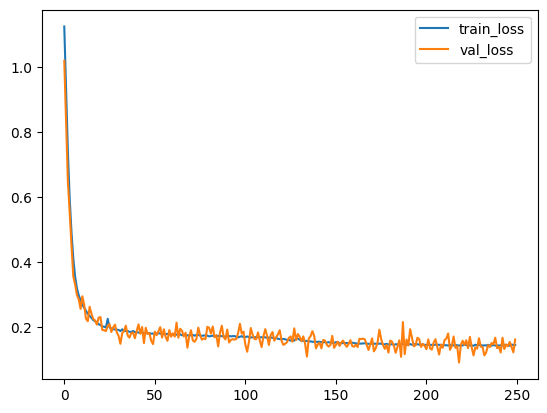

In [20]:
from typing import cast
from diffusers.optimization import get_cosine_schedule_with_warmup
import matplotlib.pyplot as plt

def train_prior(
    prior: SimpleDiffusionPrior,
    num_epochs: int,
    train_loader: DataLoader,
    val_loader: DataLoader,
    scheduler: DDPMScheduler,
    optimizer: torch.optim.Optimizer,
    criterion: nn.Module,
    lr_scheduler: torch.optim.lr_scheduler.LRScheduler,
    cond_drop_prob: float = 0.1,
    use_progress_bar: bool = True
): 
    device = cast(torch.device, next(prior.parameters()).device)
    num_training_timesteps = scheduler.config.get("num_train_timesteps")
    assert num_training_timesteps is not None
    num_training_timesteps = cast(int, num_training_timesteps)

    train_losses = []
    val_losses = []
    train_loss_value = 0
    val_loss_value = 0

    with tqdm.tqdm(total=num_epochs, disable=not use_progress_bar) as pbar:
        for epoch in range(num_epochs):
            # Training step
            prior.train()
            
            num_samples_train = 0
            train_loss = torch.zeros(1, requires_grad=False)
            for batch in train_loader:
                cond_embed = batch.get("cond_latent")
                target_embed = batch.get("target_latent")
                if torch.rand(1) < cond_drop_prob:
                    cond_embed = None

                if cond_embed is not None:
                    cond_embed = cond_embed.to(device)
                target_embed = target_embed.to(device)

                batch_size = target_embed.size(0)

                noise = torch.randn_like(target_embed)
                timesteps = torch.randint(0, num_training_timesteps, size=(batch_size,), device=device)
                noisy_latent = scheduler.add_noise(target_embed, noise, timesteps=cast(torch.IntTensor, timesteps))

                noise_pred = prior.forward(noisy_latent, timesteps, cond_embed)

                loss = criterion(noise_pred, noise)
                
                optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(prior.parameters(), 1.0)
                lr_scheduler.step()
                optimizer.step()

                num_samples_train += 1
                train_loss += loss

            # Validation
            prior.eval()

            num_samples_val = 0
            val_loss = torch.zeros(1, requires_grad=False)
            with torch.no_grad():
                for batch in val_loader:
                    cond_embed = batch.get("cond_latent")
                    target_embed = batch.get("target_latent")

                    if cond_embed is not None:
                        cond_embed = cond_embed.to(device)
                    target_embed = target_embed.to(device)

                    batch_size = target_embed.size(0)

                    noise = torch.randn_like(target_embed)
                    timesteps = torch.randint(0, num_training_timesteps, size=(batch_size,), device=device)
                    noisy_latent = scheduler.add_noise(target_embed, noise, timesteps=cast(torch.IntTensor, timesteps))

                    noise_pred = prior.forward(noisy_latent, timesteps, cond_embed)

                    loss = criterion(noise_pred, noise)

                    num_samples_val += 1
                    val_loss += loss

            
            delta_train_loss_value = train_loss.item() / num_samples_train - train_loss_value
            delta_val_loss_value = val_loss.item() / num_samples_val -val_loss_value
            train_loss_value += delta_train_loss_value
            val_loss_value += delta_val_loss_value

            pbar.update(1)
            pbar.set_description(f"train_loss: {train_loss_value:.3e} (Δ{delta_train_loss_value:.3e}) | val_loss: {val_loss_value:.3e} (Δ{delta_val_loss_value:.3e})")
            train_losses.append(train_loss_value)
            val_losses.append(val_loss_value)

    return train_losses, val_losses



num_epochs = 250
lr = 1e-3
cond_drop_prob = 0.1
criterion = nn.MSELoss()
warmup_steps = 500
train_timesteps: int = 1000

prior = SimpleDiffusionPrior()
prior.compile(fullgraph=True)
optimizer = torch.optim.Adam(prior.parameters(), lr=lr)
scheduler = DDPMScheduler(num_train_timesteps=1000)
lr_scheduler = get_cosine_schedule_with_warmup(
    optimizer=optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=(len(train_loader) * num_epochs),
)

prior_cp_path = Path("tmp/prior-eeg.pt")
new_prior_cp_path = None
TRAIN_MODEL = True
CONTINUE_TRAINING = False
if TRAIN_MODEL:
    if CONTINUE_TRAINING:
        prior.load_state_dict(torch.load(prior_cp_path))

    train_losses, val_losses = train_prior(
        prior=prior,
        num_epochs=num_epochs,
        train_loader=train_loader,
        val_loader=test_loader,
        scheduler=scheduler,
        optimizer=optimizer,
        criterion=criterion,
        lr_scheduler=lr_scheduler,
        cond_drop_prob=cond_drop_prob,
    )

    torch.save(prior.state_dict(), new_prior_cp_path or prior_cp_path)
    plt.plot(torch.arange(len(train_losses)), train_losses, label="train_loss")
    plt.plot(torch.arange(len(val_losses)), val_losses, label="val_loss")
    plt.legend()
else:
    prior.load_state_dict(torch.load(prior_cp_path))

prior.eval()
prior.to("cuda")

In [21]:
target_latents = []
pred_latents = []

scheduler = DDPMScheduler()
device = "cuda"
with torch.no_grad():
    for batch in tqdm.tqdm(test_loader):
        out = prior.generate(scheduler=scheduler, conditioning=batch["cond_latent"].to(device))
        pred_latents.extend(out.detach().cpu())
        target_latents.extend(batch["target_latent"])

target_latents = torch.stack(target_latents)
pred_latents = torch.stack(pred_latents)


100%|██████████| 200/200 [00:53<00:00,  3.75it/s]


In [22]:
import gc
gc.collect()
torch.cuda.empty_cache()

In [23]:

from brain_image.custom_ip_adapter_pipe import Generator4Embeds
pipe = Generator4Embeds()
pipe

Loading pipe...


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Pipe loaded
	Loading ip adapter...
	IP adapter loaded
Finished loading generator


In [24]:
#ex_batch = next(iter(test_loader))
scheduler = DDPMScheduler(1000)

idxs = torch.tensor([0, 1, 2, 3, 4])

pipe_out_preds = []
pipe_out_targets = []
with torch.no_grad():
    for idx in idxs:
        pipe_out_pred = pipe.generate(image_embeds=pred_latents[idx:idx+1].to(device)).detach().cpu()
        pipe_out_target = pipe.generate(image_embeds=target_latents[idx:idx+1].to(device)).detach().cpu()
        pipe_out_preds.append(pipe_out_pred)
        pipe_out_targets.append(pipe_out_target)


  0%|          | 0/4 [00:00<?, ?it/s]

/home/gasparyanartur/dev/brain-image-implementation/.venv/lib/python3.12/site-packages/diffusers/models/embeddings.py:2605: FutureWarning: You have passed a tensor as `image_embeds`.This is deprecated and will be removed in a future release. Please make sure to update your script to pass `image_embeds` as a list of tensors to suppress this warning.
  deprecate("image_embeds not a list", "1.0.0", deprecation_message, standard_warn=False)


  0%|          | 0/4 [00:00<?, ?it/s]

  0%|          | 0/4 [00:00<?, ?it/s]

  0%|          | 0/4 [00:00<?, ?it/s]

...

  0%|          | 0/4 [00:00<?, ?it/s]

  0%|          | 0/4 [00:00<?, ?it/s]

  0%|          | 0/4 [00:00<?, ?it/s]

  0%|          | 0/4 [00:00<?, ?it/s]

  0%|          | 0/4 [00:00<?, ?it/s]

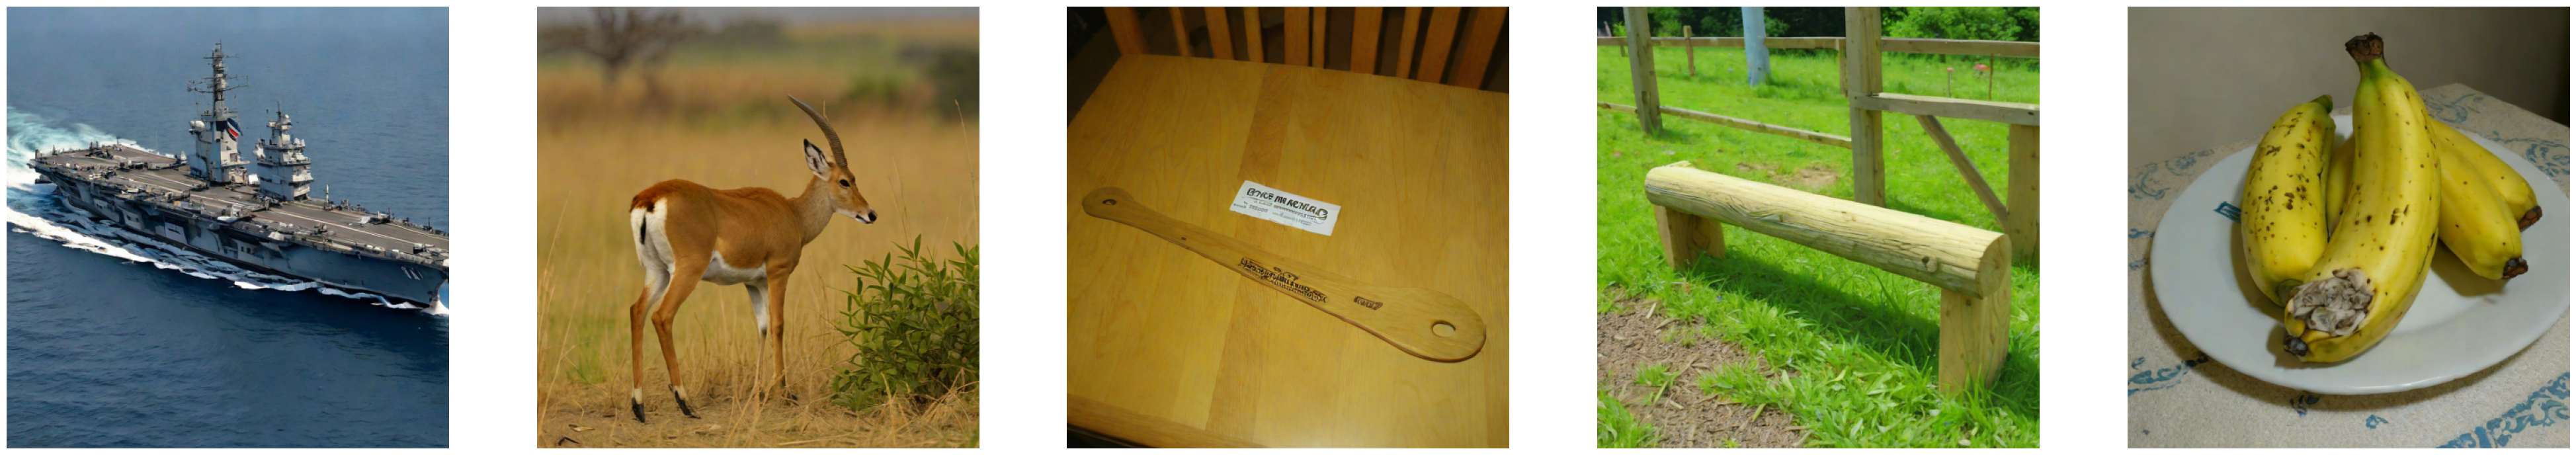

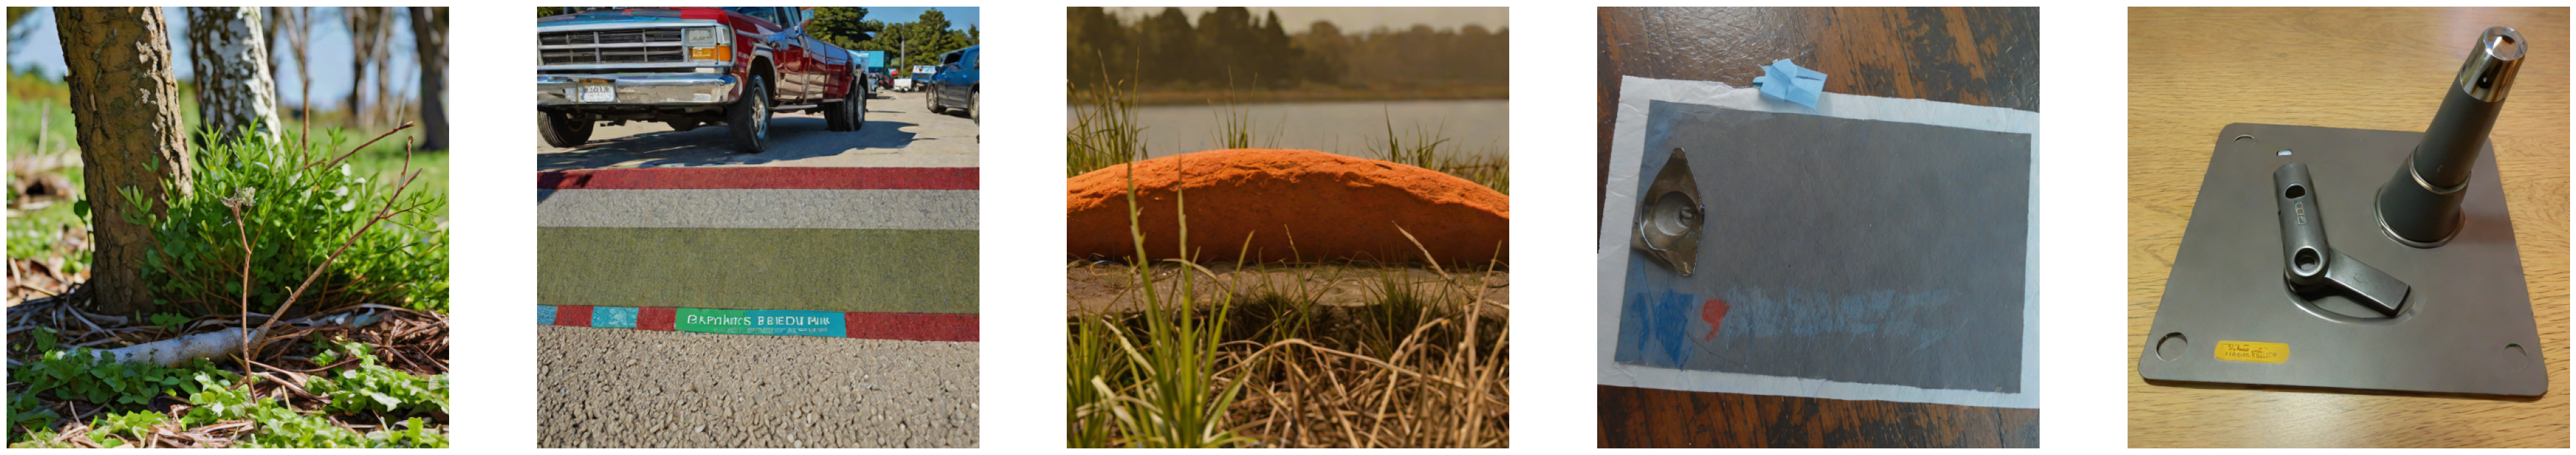

In [25]:
import matplotlib.pyplot as plt

from brain_image.utils import show_image


show_image(torch.stack(pipe_out_targets))
show_image(torch.stack(pipe_out_preds))